# Chapter 3: Dimensionality Reduction Techniques

## 1. Ringkasan Bab
Reduksi dimensi merupakan pilar fundamental dalam perancangan alur kerja machine learning untuk mengatasi kompleksitas data berskala besar (*curse of dimensionality*). Bab ini berfokus pada teknik ekstraksi fitur dan proyeksi data ke dimensi yang lebih rendah:
- **Konsep Reduksi Dimensi**: Menjaga informasi esensial data, menekan biaya komputasi, mereduksi multikolinearitas dan *noise*, serta memfasilitasi visualisasi ruang multidimensi.
- **Principal Component Analysis (PCA)**: Metode linier tanpa supervisi (*unsupervised*) yang merotasi sumbu koordinat untuk memaksimalkan variansi data ke dalam komponen utama ortogonal.
- **Linear Discriminant Analysis (LDA)**: Metode linier dengan supervisi (*supervised*) yang memproyeksikan data untuk memaksimalkan separasi antar-kelas dengan mempertimbangkan label kategori.
- **t-Distributed Stochastic Neighbor Embedding (t-SNE)**: Metode non-linier berbasis probabilitas kedekatan lokal yang ditujukan khusus untuk eksplorasi dan visualisasi struktur klaster data berdimensi tinggi ke ruang 2D atau 3D.
- **Pedoman Pemilihan Teknik**: Komparasi trade-off antara retensi variansi, separasi kelas, kemampuan transformasi data baru (*out-of-sample mapping*), dan efisiensi waktu komputasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import warnings

# Pengaturan lingkungan kerja dan penekanan pesan peringatan
np.random.seed(2024)
warnings.filterwarnings('ignore')

print("Pustaka dan dependensi Chapter 3 berhasil dimuat.")

Pustaka dan dependensi Chapter 3 berhasil dimuat.


## 2. Fondasi Teori Reduksi Dimensi

### 2.1 Mengapa Reduksi Dimensi Krusial?
Menambahkan terlalu banyak fitur ke dalam model pelatihan tanpa memperhatikan relevansi data memicu fenomena *curse of dimensionality*. Dampak negatif dimensi yang berlebihan mencakup:
1. Ruang data menjadi sangat renggang (*sparse*), sehingga jarak antar-titik kehilangan makna pembeda.
2. Waktu komputasi pelatihan model melonjak secara eksponensial.
3. Model cenderung menangkap *noise* spesifik data latih (*overfitting*) dibanding pola umum.

### 2.2 Seleksi Fitur vs Ekstraksi Fitur
- **Seleksi Fitur (Feature Selection)**: Memilih subset fitur asli tanpa mengubah representasi matematisnya (misalnya metode filter, pembungkus RFE, atau penalti Lasso).
- **Ekstraksi Fitur (Feature Extraction)**: Mengombinasikan fitur-fitur asli ke dalam ruang koordinat baru dengan jumlah dimensi yang lebih sedikit (PCA, LDA, t-SNE).

## 3. Principal Component Analysis (PCA)

PCA mencari arah proyeksi linier (disebut komponen utama) yang mempertahankan variansi terbesar dari data. Prosedur matematis PCA meliputi:
1. Standarisasi data ($\mu = 0, \sigma = 1$). Penskalaan fitur wajib dilakukan karena variabel dengan rentang nilai besar akan mendominasi arah variansi secara keliru.
2. Perhitungan matriks kovarians data $\mathbf{C}$:
   $$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^T\mathbf{X}$$
3. Dekomposisi nilai eigen (*eigenvalue*) dan vektor eigen (*eigenvector*):
   $$\mathbf{C}\mathbf{v} = \lambda\mathbf{v}$$
   Vektor eigen $\mathbf{v}$ menentukan arah sumbu komponen utama, sedangkan nilai eigen $\lambda$ merepresentasikan besaran variansi yang ditangkap oleh sumbu tersebut.

In [2]:
# Memuat dataset Wine (178 sampel, 13 fitur kimiawi, 3 kelas)
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df_wine = pd.DataFrame(data=X_wine, columns=feature_names)
print(f"Dimensi data asli: {df_wine.shape}")
print(f"Distribusi kelas : {np.bincount(y_wine)}")
display(df_wine.head(5))

Dimensi data asli: (178, 13)
Distribusi kelas : [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Membangun Pipeline: StandardScaler -> PCA (2 Komponen)
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=2024))
])

X_pca = pca_pipeline.fit_transform(df_wine)
pca_step = pca_pipeline.named_steps['pca']
evr = pca_step.explained_variance_ratio_

print(f"Variansi PC1: {evr[0]:.4f} ({evr[0]*100:.2f}%)")
print(f"Variansi PC2: {evr[1]:.4f} ({evr[1]*100:.2f}%)")
print(f"Total Variansi Tertangkap (2 Komponen): {np.sum(evr)*100:.2f}%")

Variansi PC1: 0.3620 (36.20%)
Variansi PC2: 0.1921 (19.21%)
Total Variansi Tertangkap (2 Komponen): 55.41%


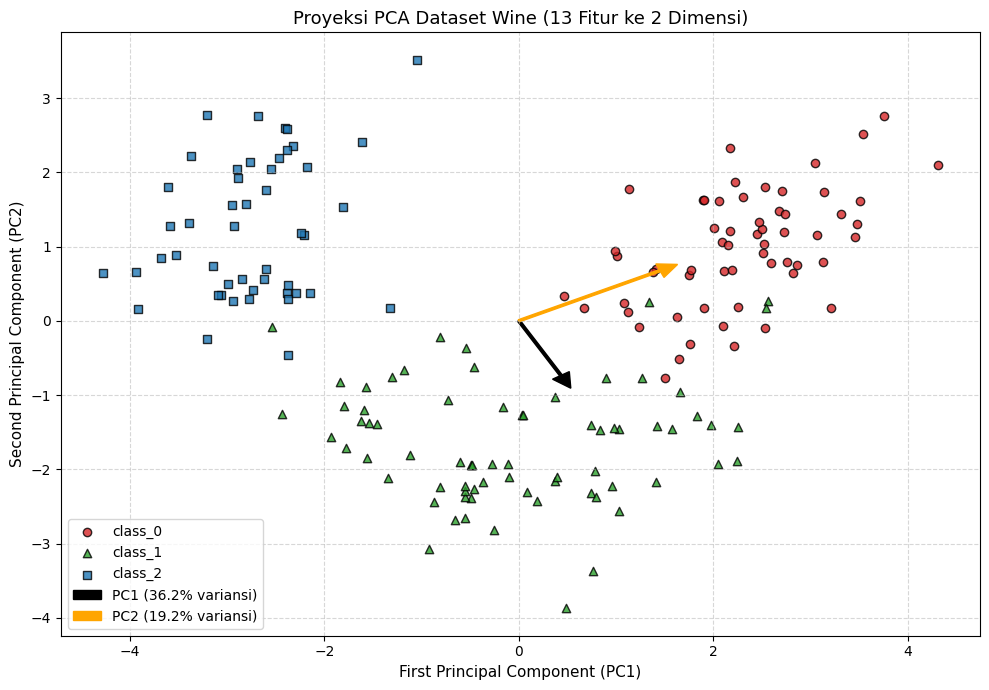

In [4]:
# Visualisasi Proyeksi 2D PCA beserta Vektor Komponen
plt.figure(figsize=(10, 7))
markers = ['o', '^', 's']
colors = ['#d62728', '#2ca02c', '#1f77b4']

for i, (marker, color) in enumerate(zip(markers, colors)):
    plt.scatter(
        X_pca[y_wine == i, 0],
        X_pca[y_wine == i, 1],
        c=color,
        marker=marker,
        label=target_names[i],
        alpha=0.8,
        edgecolors='k'
    )

# Menampilkan arah vektor komponen utama
origin = np.zeros(2)
scaling_factor = 3.0
vector_colors = ['black', 'orange']

for i, (comp, ratio) in enumerate(zip(pca_step.components_, evr)):
    plt.arrow(
        origin[0], origin[1],
        comp[0] * scaling_factor,
        comp[1] * scaling_factor,
        color=vector_colors[i],
        width=0.03,
        head_width=0.2,
        head_length=0.2,
        label=f'PC{i+1} ({ratio*100:.1f}% variansi)'
    )

plt.xlabel('First Principal Component (PC1)', fontsize=11)
plt.ylabel('Second Principal Component (PC2)', fontsize=11)
plt.title('Proyeksi PCA Dataset Wine (13 Fitur ke 2 Dimensi)', fontsize=13)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

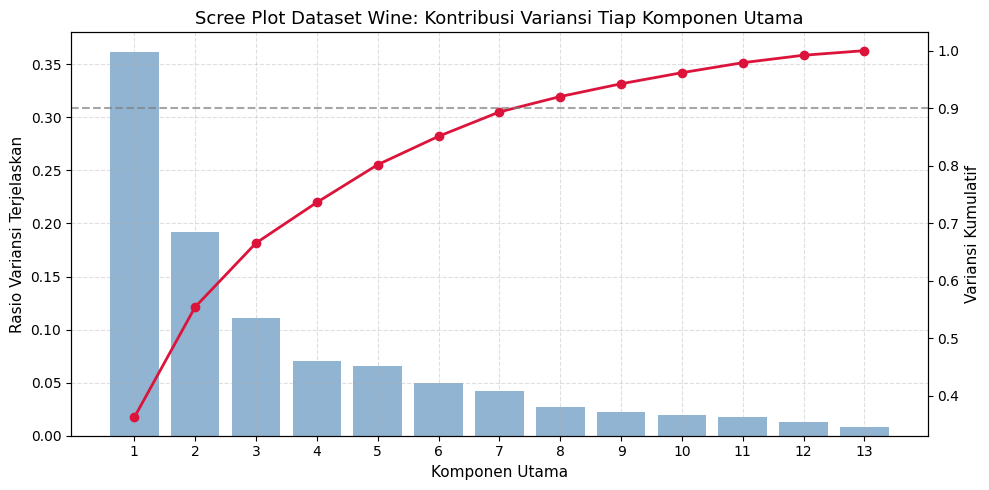

In [5]:
# Evaluasi Spektrum Variansi Seluruh Komponen Utama (Scree Plot)
pca_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=2024))
])
pca_full.fit(df_wine)

full_evr = pca_full.named_steps['pca'].explained_variance_ratio_
cum_evr = np.cumsum(full_evr)

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(range(1, len(full_evr) + 1), full_evr, alpha=0.6, color='steelblue', label='Variansi Individual')
ax1.set_xlabel('Komponen Utama', fontsize=11)
ax1.set_ylabel('Rasio Variansi Terjelaskan', fontsize=11)
ax1.set_xticks(range(1, len(full_evr) + 1))

# Garis kumulatif
ax2 = ax1.twinx()
ax2.plot(range(1, len(full_evr) + 1), cum_evr, color='crimson', marker='o', linewidth=2, label='Variansi Kumulatif')
ax2.axhline(y=0.90, color='grey', linestyle='--', alpha=0.7, label='Ambang Batas 90%')
ax2.set_ylabel('Variansi Kumulatif', fontsize=11)

plt.title('Scree Plot Dataset Wine: Kontribusi Variansi Tiap Komponen Utama', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## 4. Linear Discriminant Analysis (LDA)

Berbeda dengan PCA yang bersifat tanpa supervisi, Linear Discriminant Analysis (LDA) adalah teknik reduksi dimensi dengan supervisi (*supervised*).

LDA memproyeksikan data ke sumbu linier baru dengan kriteria optimasi ganda:
1. Memaksimalkan variansi antar-kelas (*between-class variance*, $S_B$).
2. Meminimalkan variansi di dalam internal kelas (*within-class variance*, $S_W$).

Rasio Fisher yang dimaksimalkan:
$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

Batasan dimensi LDA: jumlah komponen diskriminan maksimum yang dapat dibentuk adalah $\min(p, C - 1)$, dengan $p$ merupakan jumlah fitur dan $C$ adalah jumlah kelas. Untuk dataset Wine dengan 3 kelas, dimensi maksimal LDA adalah $3 - 1 = 2$.

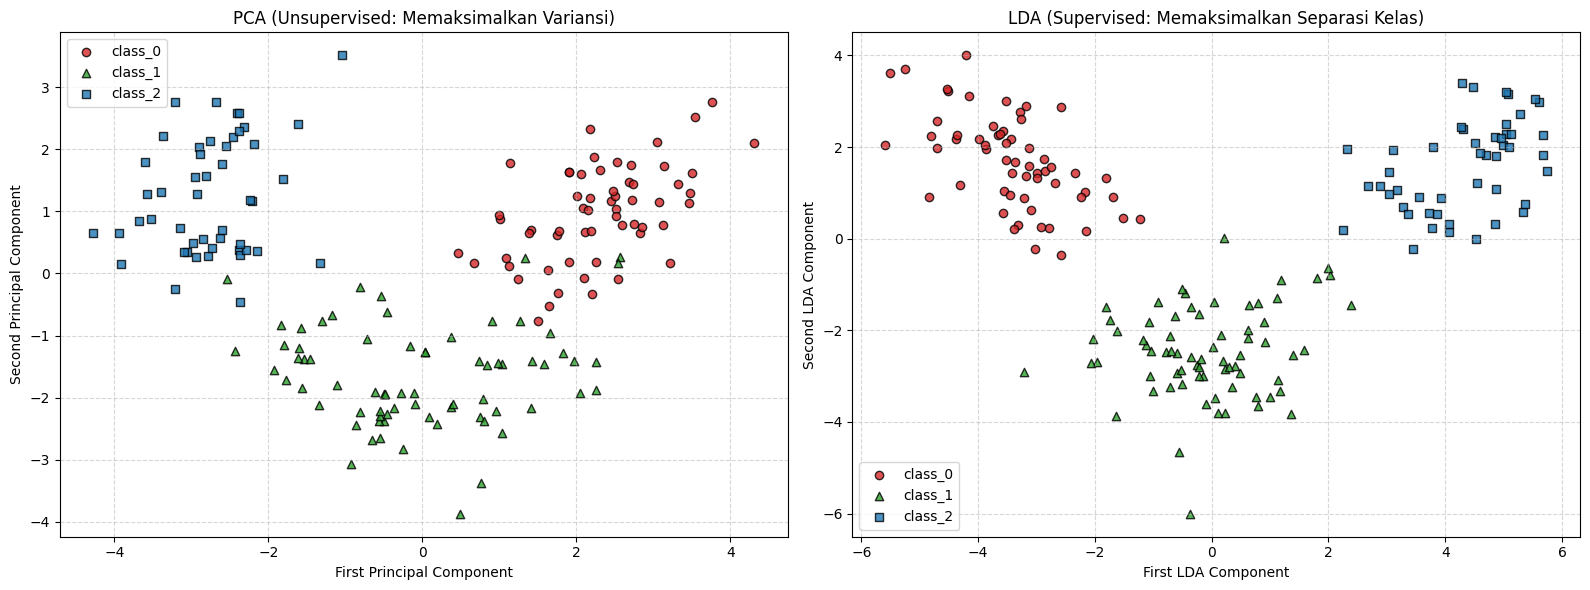

In [6]:
# Membangun Pipeline LDA (Supervised Dimensionality Reduction)
lda_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LDA(n_components=2))
])

# LDA memerlukan label target (y_wine) pada pemanggilan fit_transform
X_lda = lda_pipeline.fit_transform(X_wine, y_wine)

# Komparasi Visual Berdampingan: PCA (Unsupervised) vs LDA (Supervised)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, (marker, color) in enumerate(zip(markers, colors)):
    # Plot PCA
    ax1.scatter(
        X_pca[y_wine == i, 0], X_pca[y_wine == i, 1],
        c=color, marker=marker, label=target_names[i],
        edgecolors='k', alpha=0.8
    )
    # Plot LDA
    ax2.scatter(
        X_lda[y_wine == i, 0], X_lda[y_wine == i, 1],
        c=color, marker=marker, label=target_names[i],
        edgecolors='k', alpha=0.8
    )

ax1.set_title('PCA (Unsupervised: Memaksimalkan Variansi)', fontsize=12)
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.set_title('LDA (Supervised: Memaksimalkan Separasi Kelas)', fontsize=12)
ax2.set_xlabel('First LDA Component')
ax2.set_ylabel('Second LDA Component')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE adalah teknik reduksi dimensi non-linier berbasis *manifold learning* yang dirancang untuk memetakan struktur data kompleks ke ruang 2D atau 3D demi kebutuhan visualisasi data.

Cara kerja t-SNE:
1. Pada ruang berdimensi tinggi, jarak Euclidean antar-titik diubah menjadi probabilitas kondisional menggunakan distribusi Gaussian untuk mengukur tingkat kemiripan lokal.
2. Pada ruang berdimensi rendah, kemiripan titik dipetakan menggunakan distribusi t-Student (1 derajat kebebasan / Cauchy) untuk mengatasi permasalahan titik yang menumpuk (*crowding problem*).
3. Posisi koordinat rendah diperbarui secara iteratif dengan meminimalkan divergensi Kullback-Leibler (KL divergence) menggunakan *gradient descent*.

Catatan operasional t-SNE:
- t-SNE bersifat non-parametrik, sehingga tidak menghasilkan fungsi transformasi matematis untuk memetakan data uji baru secara langsung (tidak ada metode `.transform()` mandiri untuk data *out-of-sample*).
- Ditujukan murni sebagai instrumen eksplorasi visual data, bukan sebagai transformer umum pada pipeline inferensi produksi.

In [7]:
# Memuat dataset Citra Digit Tulisan Tangan (MNIST 8x8, 1797 sampel, 64 fitur)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Dimensi data gambar digit : {X_digits.shape}")
print(f"Jumlah kategori digit (0-9): {len(np.unique(y_digits))}")

# Membangun Pipeline t-SNE
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, perplexity=30.0, random_state=2024, max_iter=1000))
])

X_tsne = tsne_pipeline.fit_transform(X_digits)

Dimensi data gambar digit : (1797, 64)
Jumlah kategori digit (0-9): 10


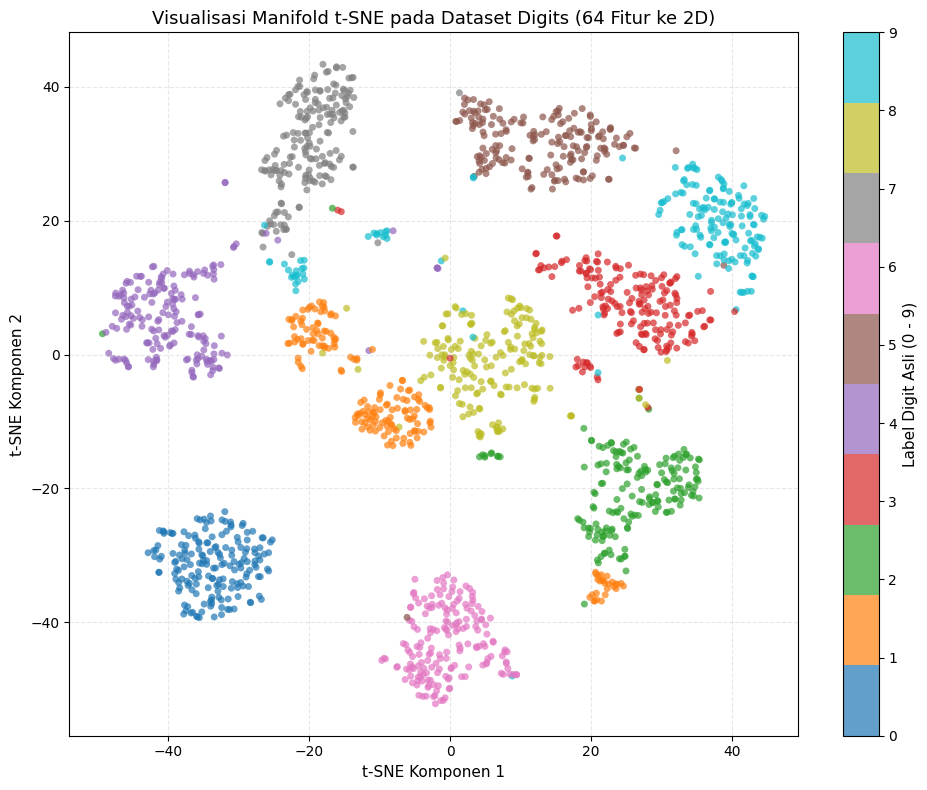

In [8]:
# Visualisasi Klaster Non-Linier t-SNE pada Dataset Digits
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_digits,
    cmap='tab10',
    alpha=0.7,
    s=25,
    edgecolors='none'
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Label Digit Asli (0 - 9)', fontsize=11)

plt.xlabel('t-SNE Komponen 1', fontsize=11)
plt.ylabel('t-SNE Komponen 2', fontsize=11)
plt.title('Visualisasi Manifold t-SNE pada Dataset Digits (64 Fitur ke 2D)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Komparasi Karakteristik dan Pedoman Pemilihan Metode

Tabel berikut menyajikan ringkasan komparasi karakteristik ketiga algoritma:

| Parameter | Principal Component Analysis (PCA) | Linear Discriminant Analysis (LDA) | t-SNE |
| :--- | :--- | :--- | :--- |
| **Tipe Algoritma** | Tanpa Supervisi (*Unsupervised*) | Dengan Supervisi (*Supervised*) | Tanpa Supervisi (*Unsupervised*) |
| **Sifat Proyeksi** | Linier ortogonal | Linier diskriminan | Non-linier (*Manifold Learning*) |
| **Fungsi Objektif** | Memaksimalkan variansi data | Memaksimalkan separasi antar-kelas | Mempertahankan struktur ketetanggaan lokal |
| **Batasan Dimensi** | $\min(n, p)$ | $\le \text{jumlah kelas} - 1$ | 2 atau 3 dimensi (tujuan visualisasi) |
| **Data Baru (*Out-of-sample*)** | Ya (dapat memanggil `.transform()`) | Ya (dapat memanggil `.transform()`) | Tidak (hanya memproses data yang ada) |
| **Tujuan Utama** | Kompresi fitur, reduksi derau | Pra-pemrosesan model klasifikasi | Eksplorasi grafis klaster data |

## 7. Analisis dan Kesimpulan
1. **Efektivitas PCA**: Pada dataset Wine, dua komponen utama pertama (PC1 dan PC2) berhasil merangkum 55.41% total variansi dari 13 fitur kimiawi asli. Berdasarkan analisis kurva scree plot, retensi variansi mencapai ambang batas di atas 90% pada 8 komponen utama.
2. **Pemisahan Kelas LDA vs PCA**: Proyeksi 2D dari LDA memperlihatkan klaster ketiga kelompok wine yang jauh lebih terpisah secara tegas dibandingkan PCA. Hal ini terjadi karena LDA secara langsung memanfaatkan informasi label target untuk meminimalkan tumpang tindih sebaran internal kelas.
3. **Representasi Manifold t-SNE**: t-SNE mampu mengurai data berdimensi 64 (citra digit tulisan tangan) menjadi 10 klaster spasial yang terisolasi dengan rapi pada ruang 2D, membuktikan keunggulannya dalam menangkap struktur topologi non-linier data yang tidak dapat dipecahkan oleh transformasi linier biasa.